**Step 1: Problem Understanding & Framing**

Frame the business and data science problem clearly.
Define whether it's a classification, regression, recommendation, anomaly detection, or clustering task.
Specify success metrics (e.g., Accuracy, AUC, RMSE, Silhouette Score) and business KPIs (e.g., cost savings, uplift).
Capstone linkage: Module 1 output maps to Capstone Steps 1–3.

**Dataset used:** *Synthetic Financial Datasets For Fraud Detection* - PaySim simulates mobile money transactions based on a sample of real transactions extracted from one month of financial logs from a mobile money service implemented in an African country. The original logs were provided by a multinational company, who is the provider of the mobile financial service which is currently running in more than 14 countries all around the world. This has ~6.3M trsnactions with varying transaction types (cash-in, cash-out, debit, payment and transfer), origin and destination account balances before and after thr transaction and an internal tagging of which ones can be fraud.

**Task type:** Binary classification, extreme class imbalance since fraudulent transactions are very small.

**Target metrics:**


*  Model - Recall and PR-AUC on the fraud classification; Accuracy will not be considered since if the model will predict legitimate transactions will catch zero fraud
*  Business metrics - estimated value of fraud loss prevented vs cost of blocking false-positive legitimate transactions.



**Problem Statement:** Fraudulent transactions via mobile phones or digital have been the default platform for many banking users. This impacts the organization financially through reimbursing transactions to the customers. Additionally, this yield reputational impact by losing customer trust. With the volume of transactions happening, manual review to flag which transactions are indeed fraudulent is not sustainable. The goal is to flag high-risk transactions in near-real-time to automatically prevent the fraud from happening or send for human review.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
np.random.seed(42)

**Public dataset from Kaggle:** Synthetic Financial Datasets For Fraud Detection by Edgar Lopez-Rojas (Owner).

In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/capstone/data/PS_20174392719_1491204439457_log.csv')
data_dict = pd.read_csv('/content/drive/MyDrive/capstone/data/Data_Dictionary.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Summary of features:**

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
step,6362620.0,NaN,NaN,NaN,243.397246,142.331971,1.0,156.0,239.0,335.0,743.0
type,6362620,5,CASH_OUT,2237500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,6362620.0,NaN,NaN,NaN,179861.903549,603858.231463,0.0,13389.57,74871.94,208721.4775,92445516.64
nameOrig,6362620,6353307,C1530544995,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldbalanceOrg,6362620.0,NaN,NaN,NaN,833883.104074,2888242.673007,0.0,0.0,14208.0,107315.175,59585040.37
newbalanceOrig,6362620.0,NaN,NaN,NaN,855113.668579,2924048.502971,0.0,0.0,0.0,144258.41,49585040.37
nameDest,6362620,2722362,C1286084959,113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldbalanceDest,6362620.0,NaN,NaN,NaN,1100701.66652,3399180.112969,0.0,0.0,132705.665,943036.7075,356015889.35
newbalanceDest,6362620.0,NaN,NaN,NaN,1224996.398202,3674128.942094,0.0,0.0,214661.44,1111909.25,356179278.92
isFraud,6362620.0,NaN,NaN,NaN,0.001291,0.035905,0.0,0.0,0.0,0.0,1.0


In [6]:
type_fraud = pd.crosstab(df['type'], df['isFraud'], normalize='index') * 100
type_fraud.columns = ['pct_legitimate', 'pct_fraud']
type_fraud.sort_values('pct_fraud', ascending=False)

,pct_legitimate,pct_fraud
type,,
TRANSFER,99.231201,0.768799
CASH_OUT,99.816045,0.183955
CASH_IN,100.000000,0.000000
DEBIT,100.000000,0.000000
PAYMENT,100.000000,0.000000


IQR upper fence: 501,719.34
Transactions above fence: 338078 (5.31%)


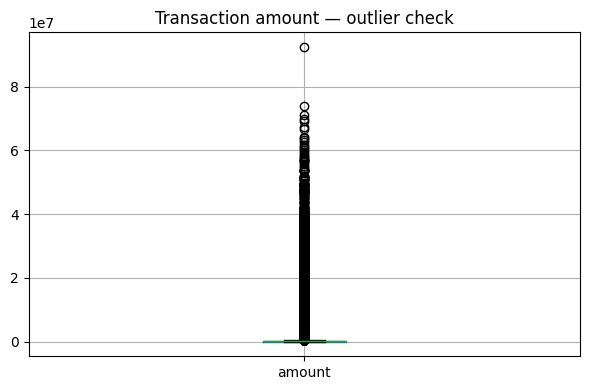

In [7]:
q1, q3 = df['amount'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
n_outliers = (df['amount'] > upper_fence).sum()
print(f"IQR upper fence: {upper_fence:,.2f}")
print(f"Transactions above fence: {n_outliers} ({n_outliers / len(df) * 100:.2f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
df.boxplot(column='amount', ax=ax)
ax.set_title('Transaction amount — outlier check')
plt.tight_layout()
plt.show()


In [8]:
df.groupby('isFraud')['amount'].mean()

,amount
isFraud,
0,1.781970e+05
1,1.467967e+06


In [9]:
# 1. Missing values
df.isna().sum()

# 2. Duplicate rows
df.duplicated().sum()

# 3. Class balance
df['isFraud'].value_counts()
df['isFraud'].value_counts(normalize=True) * 100

,proportion
isFraud,
0,99.870918
1,0.129082


**Step 2: Data Collection & Understanding**

Use public datasets (Kaggle, UCI, APIs, etc.) or approved custom data.
Summarise feature types, missing values, outliers, etc.
Provide a data dictionary (variables, types, units, allowed values).
Deliverable: Dataset overview + data dictionary.

In [10]:
# 1. Missing values
df.isna().sum()

# 2. Duplicate rows
df.duplicated().sum()

np.int64(0)

In [11]:
df.dtypes

,0
step,int64
type,object
amount,float64
nameOrig,object
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,object
oldbalanceDest,float64
newbalanceDest,float64
isFraud,int64


In [12]:
df['type'].unique()
df['nameOrig'].head()
df['nameDest'].head()

,nameDest
0,M1979787155
1,M2044282225
2,C553264065
3,C38997010
4,M1230701703


In [13]:
df['type'].unique()

array(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'],
      dtype=object)

**Allowed values:** PAYMENT, TRANSFER, CASH_OUT, DEBIT, CASH_IN


**Units:** amount, oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest

**Data dictionary:**

In [14]:
!ls /content/drive/MyDrive/capstone/data/.

Data_Dictionary.csv	PS_20174392719_1491204439457_log.csv
Data_Dictionary.gsheet


In [15]:
data_dict = pd.read_csv('/content/drive/MyDrive/capstone/data/Data_Dictionary.csv')
data_dict

,Column,Type,Description
0,step,int64,"Unit of time; 1 step is equivalent to an hour,..."
1,type,object,"Transaction type, whether it's cash in, cash o..."
2,amount,float64,Transaction amount in used currency
3,nameOrig,object,Name of the originating account
4,oldbalanceOrg,float64,Account balance before executing the transacti...
5,newbalanceOrig,float64,Account balance after executing the transactio...
6,nameDest,object,Name of the destination / receiving account
7,oldbalanceDest,float64,Account balance before executing the transacti...
8,newbalanceDest,float64,Account balance after executing the transactio...
9,isFraud,int64,Tagging if the transaction is fraudulent


**Step 3: Data Preprocessing, Applied EDA & Feature Engineering**

Clean data: Handle nulls, duplicates and outliers.
Engineer features: Scaling, encoding, binning and domain-derived features.
Applied EDA: Distributions, relationships, clustering tendency (if unsupervised).
Feature importance & explainability: SHAP, LIME, or model-based importances.
Feature selection: At least one approach (filter, wrapper, or embedded).
Dimensionality reduction: PCA (and t-SNE/UMAP for visualisation if needed).
Deliverable: "EDA + Feature Engineering Report" with reproducible code & justifications.

In [16]:
df.groupby('type')['isFraud'].mean() * 100

,isFraud
type,
CASH_IN,0.000000
CASH_OUT,0.183955
DEBIT,0.000000
PAYMENT,0.000000
TRANSFER,0.768799


**Findings:** Fraud only occurs in two transaction types: TRANSFER (0.77%) and CASH_OUT (0.18%). The rest of the transaction types have 0% fraud transactions.
1. CASH_IN - structurally, this adds balance to the account. There is no account to drain fraudulently.
2. PAYMENT is where money is transferred to a merchant (tagged as M) so balance cannot be withdrawn.
3. DEBIT is structurally able to drain the account, however, transactions can be small. The mean is $5484, whereas the largest transaction is $569,078. With this, DEBIT is excluded by scale.

In [17]:
df.groupby('type')['nameDest'].apply(lambda x: x.str[0].unique())

,nameDest
type,
CASH_IN,[C]
CASH_OUT,[C]
DEBIT,[C]
PAYMENT,[M]
TRANSFER,[C]


In [18]:
df['type'].value_counts()

,count
type,
CASH_OUT,2237500
PAYMENT,2151495
CASH_IN,1399284
TRANSFER,532909
DEBIT,41432


In [19]:
df[df['type'] == 'CASH_IN'][['oldbalanceOrg', 'newbalanceOrig']].describe()

,oldbalanceOrg,newbalanceOrig
count,1.399284e+06,1.399284e+06
mean,3.590464e+06,3.759379e+06
std,5.291825e+06,5.287487e+06
min,0.000000e+00,5.440000e+00
25%,3.776800e+04,2.497569e+05
50%,1.200093e+06,1.369115e+06
75%,5.284255e+06,5.450491e+06
max,3.893942e+07,3.894623e+07


In [20]:
df[df['type'] == 'DEBIT'][['oldbalanceOrg', 'newbalanceOrig']].describe()

,oldbalanceOrg,newbalanceOrig
count,4.143200e+04,4.143200e+04
mean,6.864734e+04,6.516165e+04
std,1.384493e+05,1.376566e+05
min,0.000000e+00,0.000000e+00
25%,1.518500e+03,0.000000e+00
50%,2.082111e+04,1.663242e+04
75%,6.880661e+04,6.263080e+04
max,4.362014e+06,4.359375e+06


In [21]:
df[df['type'] == 'DEBIT'][['amount']].describe()

,amount
count,41432.000000
mean,5483.665314
std,13318.535518
min,0.550000
25%,1500.180000
50%,3048.990000
75%,5479.175000
max,569077.510000


In [22]:
df['errorBalanceOrig'] = df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']

df.groupby('isFraud')['errorBalanceOrig'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,-201338.558109,606928.890826,-92445516.64,-249953.43,-69049.31,-3034.305,1.000000e-02
1,8213.0,-10692.325265,265146.131130,-10000000.00,0.00,0.00,0.000,3.725290e-09


In [23]:
df['near_zero_error'] = df['errorBalanceOrig'].abs() < 1
df.groupby('isFraud')['near_zero_error'].mean() * 100

,near_zero_error
isFraud,
0,21.302822
1,99.452088


**Finding:** errorBalanceOrig is the key engineered feature. It measures oldBalanceOrg - amount - newbalanceOrig. It looks at how far the account's ending balance from the transaction account implies. 99.45% of fraud transactions land within $1 of zero, compared against 21.3% of legitimate transactions. This happens due to the fact that fraudulent transactions drain the account leaving newBalanceOrig with 0. This is aligned with the fraud's 25th, 50th and 75th percentile of 0. The destination-side equivalent account shows 48.4% vs 39.9% near zero.

In [24]:
df[df['isFraud'] == 0].groupby('type')['near_zero_error'].mean() * 100

,near_zero_error
type,
CASH_IN,0.000214
CASH_OUT,11.296087
DEBIT,71.560629
PAYMENT,48.823121
TRANSFER,4.028653


In [25]:
df[df['isFraud'] == 1]['newbalanceOrig'].describe()

,newbalanceOrig
count,8.213000e+03
mean,1.923926e+05
std,1.965666e+06
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,4.958504e+07


In [26]:
type_dummies = pd.get_dummies(df['type'], prefix='type')
df = pd.concat([df, type_dummies], axis=1)

In [27]:
df[[c for c in df.columns if c.startswith('type_')]].sum()

,0
type_CASH_IN,1399284
type_CASH_OUT,2237500
type_DEBIT,41432
type_PAYMENT,2151495
type_TRANSFER,532909


In [28]:
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']
df.groupby('isFraud')['errorBalanceDest'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,54692.231734,4.360026e+05,-75885725.63,0.0,3500.68,29259.805,13191233.98
1,8213.0,732509.301069,1.867748e+06,-8875516.29,0.0,2231.46,442722.010,10000000.00


In [29]:
df['dest_near_zero_error'] = df['errorBalanceDest'].abs() < 1
df.groupby('isFraud')['dest_near_zero_error'].mean() * 100

,dest_near_zero_error
isFraud,
0,39.890567
1,48.423231


In [30]:
df.groupby(df['nameDest'].str[0])[['oldbalanceDest', 'newbalanceDest']].mean()

,oldbalanceDest,newbalanceDest
nameDest,,
C,1.663058e+06,1.850856e+06
M,0.000000e+00,0.000000e+00


In [31]:
df['isMerchantDest'] = df['nameDest'].str[0] == 'M'

In [32]:
from sklearn.preprocessing import StandardScaler

numeric_features = ['amount', 'oldbalanceOrg', 'newbalanceOrig',
                     'oldbalanceDest', 'newbalanceDest',
                     'errorBalanceOrig', 'errorBalanceDest']

scaler = StandardScaler()
scaled = scaler.fit_transform(df[numeric_features])

In [33]:
import pandas as pd
pd.DataFrame(scaled, columns=numeric_features).describe()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,errorBalanceOrig,errorBalanceDest
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,-4.946736e-17,-1.779646e-17,6.590049e-16,1.498762e-16,-1.340452e-16,-5.278365e-16,-1.840397e-18
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-2.978545e-01,-2.887164e-01,-2.924417e-01,-3.238139e-01,-3.334114e-01,-1.520553e+02,-1.719963e+02
25%,-2.756812e-01,-2.887164e-01,-2.924417e-01,-3.238139e-01,-3.334114e-01,-8.002734e-02,-1.258518e-01
50%,-1.738653e-01,-2.837972e-01,-2.924417e-01,-2.847734e-01,-2.749863e-01,2.182727e-01,-1.179237e-01
75%,4.779197e-02,-2.515606e-01,-2.431065e-01,-4.638324e-02,-3.077931e-02,3.266102e-01,-5.937128e-02
max,1.527936e+02,2.034149e+01,1.666523e+01,1.044120e+02,9.660911e+01,3.314800e-01,2.975042e+01


In [34]:
df['amountBin'] = pd.qcut(df['amount'], q=4, labels=['Q1_low', 'Q2', 'Q3', 'Q4_high'])

In [35]:
df['amountBin'].value_counts()

,count
amountBin,
Q1_low,1590656
Q3,1590655
Q4_high,1590655
Q2,1590654


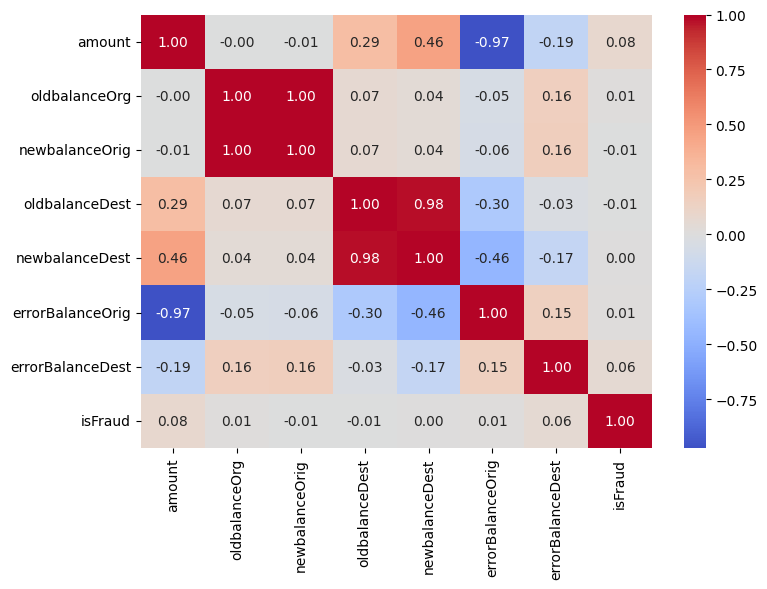

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_cols = numeric_features + ['isFraud']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
plt.tight_layout()
plt.show()

**Finding:** The heatmap is unable to show that errorBalanceOrig correlated with isFraud with only 0.01. However, it ranks first in the Random Forest importance in the next cells. Pearson correlation only detects straight-line relationships. Since errorBalanceOrig is a cluster at one point, it's not detected. The heatmap also shows multicollinearity oldBalanceOrg and newBalanceOrig at 1.00, oldBalanceDest and newBalanceDest at 0.98. This makes Logistic Regression unstable, hence the ranking is not reliable.

In [37]:
df['isMerchantDest'].sum()

np.int64(2151495)

In [38]:
df['isFlaggedFraud'].value_counts()
df.groupby('isFraud')['isFlaggedFraud'].sum()

,isFlaggedFraud
isFraud,
0,0
1,16


In [39]:
import numpy as np

feature_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest',
                 'errorBalanceOrig', 'errorBalanceDest', 'isMerchantDest'] + \
                [c for c in df.columns if c.startswith('type_')]

rng = np.random.default_rng(42)
fraud_idx = df.index[df['isFraud'] == 1]
legit_sample_idx = rng.choice(df.index[df['isFraud'] == 0], size=50_000, replace=False)
sample_idx = np.concatenate([fraud_idx, legit_sample_idx])

X_sample = df.loc[sample_idx, feature_cols]
y_sample = df.loc[sample_idx, 'isFraud']

In [40]:
X_sample.shape
y_sample.mean()

np.float64(0.14108532458385584)

In [41]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=150, max_depth=10, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_sample, y_sample)

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances

,0
errorBalanceOrig,0.398891
oldbalanceOrg,0.141986
newbalanceOrig,0.132436
amount,0.084382
type_PAYMENT,0.053114
isMerchantDest,0.043808
type_TRANSFER,0.034298
errorBalanceDest,0.026425
type_CASH_IN,0.026257
oldbalanceDest,0.022384


In [42]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = pd.Series(
    mutual_info_classif(X_sample, y_sample, random_state=42),
    index=feature_cols
).sort_values(ascending=False)
mi_scores

,0
errorBalanceOrig,0.190674
oldbalanceOrg,0.173465
amount,0.161605
errorBalanceDest,0.071864
type_TRANSFER,0.067832
newbalanceOrig,0.062666
type_PAYMENT,0.058900
isMerchantDest,0.054048
type_CASH_IN,0.033727
oldbalanceDest,0.017276


**Final feature set:** amount, oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest, errorBalanceOrig, errorBalanceDest, type_TRANSFER, type_CASH_OUT, isMerchantDest.

Methods rank errorBalanceOrig first (Random Forest 0.399, MI 0.191)

type_CASH_OUT is kept despite low scores in Random Forest and mutual information. Fraud is only possible in CASH_OUT and TRANSFER, however, it is too strong a domain fact to drop due to a low statistical score.

type_CASH_IN, type_DEBIT, type_PAYMENT are excluded due to 0% fraud case.

isFlaggedFraud is excluded due to low fraud capture against cases. However, the number is noted as baseline for model result comparison.

In [43]:
from sklearn.decomposition import PCA

pca = PCA(random_state=42)
pca_full = pca.fit(scaled)
pca_full.explained_variance_ratio_

array([3.97988311e-01, 2.93142134e-01, 1.76271798e-01, 1.28549122e-01,
       4.04863542e-03, 2.00847520e-15, 0.00000000e+00])

In [44]:
np.cumsum(pca_full.explained_variance_ratio_)

array([0.39798831, 0.69113044, 0.86740224, 0.99595136, 1.        ,
       1.        , 1.        ])

In [45]:
np.corrcoef(df['oldbalanceOrg'], df['newbalanceOrig'])[0,1]

np.float64(0.9988027631722983)

**Dimensionality reduction:** PCA was run of 7 scaled features whereas 99.6% of the variance are captured by 4 components. Features were scaled first. If left unscaled, the million-scale balance columns would dominate the results.

**Step 4: Model Implementation**

Experiment with appropriate models:
Supervised: Logistic Regression, Decision Trees, Random Forest, XGBoost, SVM, etc.
Unsupervised: K-Means, DBSCAN, Hierarchical (Elbow, Silhouette).
Recommendation: Collaborative or content-based.
Deep Learning: RNNs, CNNs, LSTMs, Transformers (if appropriate).
Evaluation: compare with relevant metrics.
Reproducibility: save configs and artefacts (models/).
Deliverables: Trained models, metrics and comparison between models.

In [46]:
from sklearn.model_selection import train_test_split

In [47]:
FINAL_FEATURES = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest',
                   'errorBalanceOrig', 'errorBalanceDest', 'type_TRANSFER', 'type_CASH_OUT', 'isMerchantDest']
X = df[FINAL_FEATURES].astype('float32')
y = df['isFraud'].astype('int8')

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print(f"Train: {X_train.shape[0]:,} rows, {y_train.sum()} fraud ({y_train.mean()*100:.4f}%)")
print(f"Test:  {X_test.shape[0]:,} rows, {y_test.sum()} fraud ({y_test.mean()*100:.4f}%)")

Train: 4,453,834 rows, 5749 fraud (0.1291%)
Test:  1,908,786 rows, 2464 fraud (0.1291%)


In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import joblib

In [50]:
scale_pos_weight = (y_train == 0).sum ()  / (y_train==1).sum()
print(scale_pos_weight)


773.7145590537485


**Class-balance:** With SMOTE, balancing the training set would require generating ~4M synthetic fraud (translates to ~773 per real fraud case). This would be computationally wasteful. The class_weight='balanced' for Logistic Regression and Random Forest, and scale_pos_weight for XGBoost would make missed fraud to cost more without the need to create more synthetic data.

In [51]:
scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [52]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
joblib.dump(lr, '/content/drive/MyDrive/capstone/models/logistic_regression.joblib')
print("lr fitted:", hasattr(lr, 'coef_'))

lr fitted: True


In [53]:
rf = RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
joblib.dump(rf, '/content/drive/MyDrive/capstone/models/random_forest.joblib')
print("rf fitted:", hasattr(rf, 'estimators_'))

rf fitted: True


In [54]:
xgb_model = XGBClassifier(n_estimators=200, max_depth=6, scale_pos_weight=1, random_state=42)
xgb_model.fit(X_train, y_train)
joblib.dump(xgb_model, '/content/drive/MyDrive/capstone/models/xgboost.joblib')
print("xgb fitted:", hasattr(xgb_model, 'feature_importances_'))

xgb fitted: True


In [55]:
!ls -la /content/drive/MyDrive/capstone/models/

total 1482
drwx------ 2 root root    4096 Sep 22 16:33 .
drwx------ 4 root root    4096 Sep 17 11:04 ..
-rw------- 1 root root     943 Sep 22 16:14 logistic_regression.joblib
-rw------- 1 root root 1232297 Sep 22 16:31 random_forest.joblib
-rw------- 1 root root    1271 Sep 18 06:51 scaler.joblib
-rw------- 1 root root  274215 Sep 22 16:33 xgboost.joblib


In [56]:
print(hasattr(lr, 'coef_'))
print(hasattr(rf, 'estimators_'))
print(hasattr(xgb_model, 'feature_importances_'))

True
True
True


In [57]:
import os
os.makedirs('/content/drive/MyDrive/capstone/models', exist_ok=True)

In [58]:
!ls /content/drive/MyDrive/capstone/models/

logistic_regression.joblib  random_forest.joblib  scaler.joblib  xgboost.joblib


In [59]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

In [60]:
print(len(rf.estimators_))

100


In [61]:
models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'XGBoost': xgb_model
}

results = []

for name, model in models.items():
    X_eval = X_test_scaled if name == 'Logistic Regression' else X_test

    proba = model.predict_proba(X_eval)[:, 1]
    pred = (proba >= 0.5).astype(int)

    results.append({
        'Model': name,
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba),
        'PR-AUC': average_precision_score(y_test, proba),
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df

,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,
Logistic Regression,0.022563,0.939935,0.044068,0.989082,0.544061
Random Forest,1.000000,0.996347,0.998170,0.999578,0.997891
XGBoost,0.998779,0.995942,0.997358,0.999524,0.997070


In [62]:
xgb_weighted = XGBClassifier(n_estimators=200, max_depth=6,
                                scale_pos_weight=scale_pos_weight, random_state=42)
xgb_weighted.fit(X_train, y_train)
proba_w = xgb_weighted.predict_proba(X_test)[:, 1]
pred_w = (proba_w >= 0.5).astype(int)
print(f"Precision: {precision_score(y_test, pred_w):.4f}")
print(f"Recall: {recall_score(y_test, pred_w):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, proba_w):.4f}")

Precision: 0.1591
Recall: 0.9919
PR-AUC: 0.1584


In [63]:
xgb_unweighted = XGBClassifier(n_estimators=200, max_depth=6, scale_pos_weight=1, random_state=42)
xgb_unweighted.fit(X_train, y_train)

proba_uw = xgb_unweighted.predict_proba(X_test)[:, 1]
pred_uw = (proba_uw >= 0.5).astype(int)

print(f"Precision: {precision_score(y_test, pred_uw):.4f}")
print(f"Recall: {recall_score(y_test, pred_uw):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, proba_uw):.4f}")

Precision: 0.9988
Recall: 0.9959
PR-AUC: 0.9971


**Finding:** Tuning scale_pos_weight to the 774 which yielded Precision and PR-AUC with 0.159 and 0.158 respectively, which means the model has flagged legitimate transactions as fraudulent. Adjusting scale_pos_weight to 1 significantly improved Precision and PR-AUC to 0.999 and 0.997 respectively without sacrificing recall.

In [64]:
ablation_features = [f for f in FINAL_FEATURES if f not in ('errorBalanceOrig', 'errorBalanceDest')]

xgb_ablation = XGBClassifier(n_estimators=200, max_depth=6, scale_pos_weight=1, random_state=42)
xgb_ablation.fit(X_train[ablation_features], y_train)

proba_abl = xgb_ablation.predict_proba(X_test[ablation_features])[:, 1]
pred_abl = (proba_abl >= 0.5).astype(int)

print(f"Precision: {precision_score(y_test, pred_abl):.4f}")
print(f"Recall: {recall_score(y_test, pred_abl):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, proba_abl):.4f}")

Precision: 0.2901
Recall: 0.2597
PR-AUC: 0.1263


**Finding:** Removing the engineered features, errorBalanceOrig and errorBalanceDest collapses PR-AUC from 0.997 to 0.126.

In [65]:
proba_rf = rf.predict_proba(X_test)[:, 1]

In [66]:
thresholds = np.arange(0.05, 1.0, 0.05)
for t in thresholds:
    pred_t = (proba_rf >= t).astype(int)
    print(f"{t:.2f}  Precision: {precision_score(y_test, pred_t):.4f}  Recall: {recall_score(y_test, pred_t):.4f}")

0.05  Precision: 0.6901  Recall: 0.9980
0.10  Precision: 0.8643  Recall: 0.9976
0.15  Precision: 0.8941  Recall: 0.9972
0.20  Precision: 0.9010  Recall: 0.9972
0.25  Precision: 0.9300  Recall: 0.9972
0.30  Precision: 0.9403  Recall: 0.9972
0.35  Precision: 0.9951  Recall: 0.9963
0.40  Precision: 0.9992  Recall: 0.9963
0.45  Precision: 1.0000  Recall: 0.9963
0.50  Precision: 1.0000  Recall: 0.9963
0.55  Precision: 1.0000  Recall: 0.9963
0.60  Precision: 1.0000  Recall: 0.9963
0.65  Precision: 1.0000  Recall: 0.9963
0.70  Precision: 1.0000  Recall: 0.9955
0.75  Precision: 1.0000  Recall: 0.9943
0.80  Precision: 1.0000  Recall: 0.9935
0.85  Precision: 1.0000  Recall: 0.9927
0.90  Precision: 1.0000  Recall: 0.9890
0.95  Precision: 1.0000  Recall: 0.9801


**Commentary:** Precision stays at 1.00 and recall with 0.996 in several thresholds. If threshold is lowered below 0.5, it barely improves recall but reduces precision.

**Step 5: Critical Thinking → Ethical AI & Bias Auditing**

Explain model decisions (SHAP, LIME, PDP, ICE).
Address limitations (imbalance, leakage, overfitting).
Bias detection & fairness audits:
Check outputs across sensitive groups (gender, race, age, socioeconomic status).
Use fairness metrics (demographic parity, equalised odd, disparate impact).
Propose mitigations (reweighting, thresholds, augmentation, post-processing).
Deliverable: "Bias & Fairness Analysis" section in the final report.

**Check for overfitting:**

In [67]:
# Train set
proba_train = rf.predict_proba(X_train)[:, 1]
pred_train = (proba_train >= 0.5).astype(int)

print("TRAIN")
print("Precision:", precision_score(y_train, pred_train))
print("Recall:", recall_score(y_train, pred_train))
print("PR-AUC:", average_precision_score(y_train, proba_train))

TRAIN
Precision: 1.0
Recall: 0.99826056705514
PR-AUC: 0.9999704299211364


In [68]:
# TEST set
proba_test = rf.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= 0.5).astype(int)

print("TEST")
print("Precision:", precision_score(y_test, pred_test))
print("Recall:", recall_score(y_test, pred_test))
print("PR-AUC:", average_precision_score(y_test, proba_test))

TEST
Precision: 1.0
Recall: 0.9963474025974026
PR-AUC: 0.9978911943081349


**SHAP:**

In [69]:
import shap

In [70]:
shap_sample = X_test.sample(3000, random_state=42)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(shap_sample)

In [71]:
type(shap_values)

numpy.ndarray

In [72]:
shap_values.shape

(3000, 10, 2)

In [73]:
sv = shap_values[:,:,1]

In [74]:
sv.shape

(3000, 10)

/tmp/ipykernel_121640/3967279167.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, shap_sample)


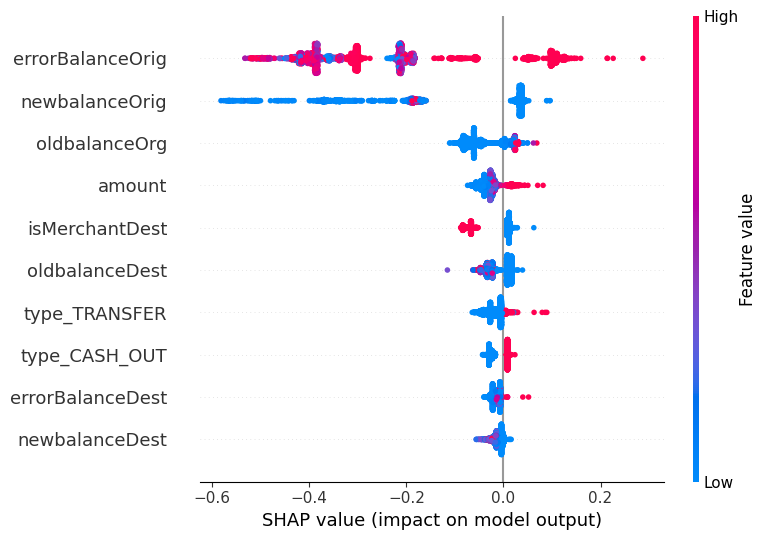

In [75]:
shap.summary_plot(sv, shap_sample)

/tmp/ipykernel_121640/1022572140.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, shap_sample, plot_type='bar')


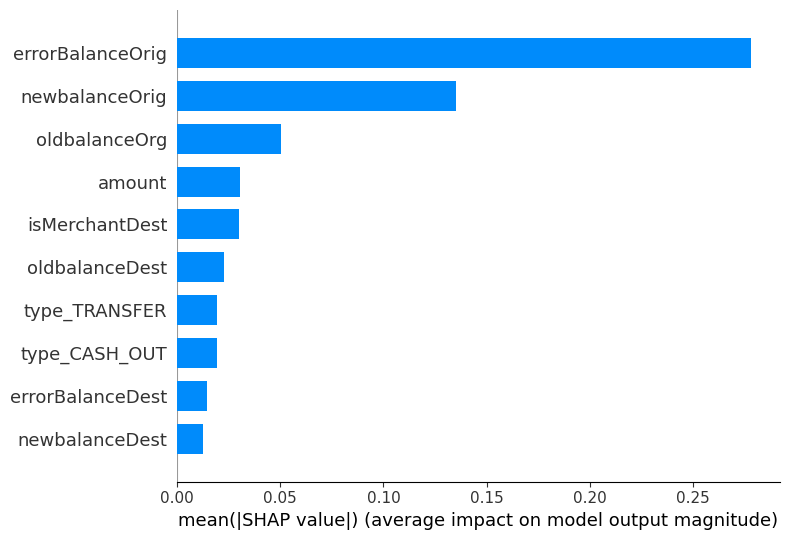

In [76]:
shap.summary_plot(sv, shap_sample, plot_type='bar')

In [77]:
fraud_idx = y_test[y_test == 1].index
legit_sample_idx = y_test[y_test == 0].sample(3000, random_state=42).index
balanced_sample_idx = fraud_idx.append(legit_sample_idx)

shap_sample = X_test.loc[balanced_sample_idx]

/tmp/ipykernel_121640/1627956166.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, shap_sample)


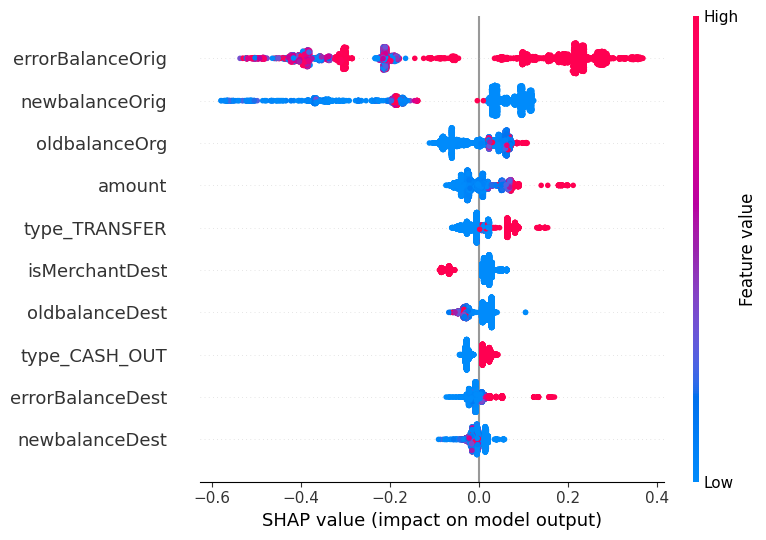

/tmp/ipykernel_121640/1627956166.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, shap_sample, plot_type='bar')


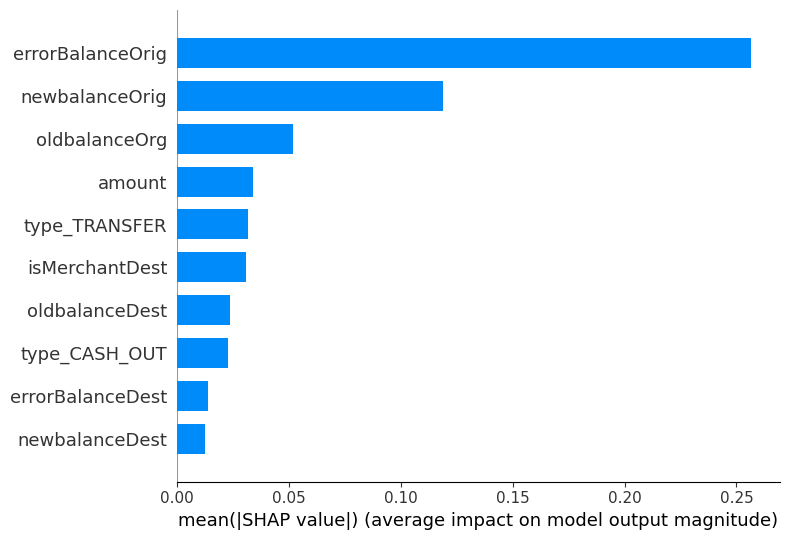

In [78]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(shap_sample)
sv = shap_values[:, :, 1]

shap.summary_plot(sv, shap_sample)
shap.summary_plot(sv, shap_sample, plot_type='bar')

In [79]:
pdp_sample = X_test.sample(5000, random_state=42).astype('float64')

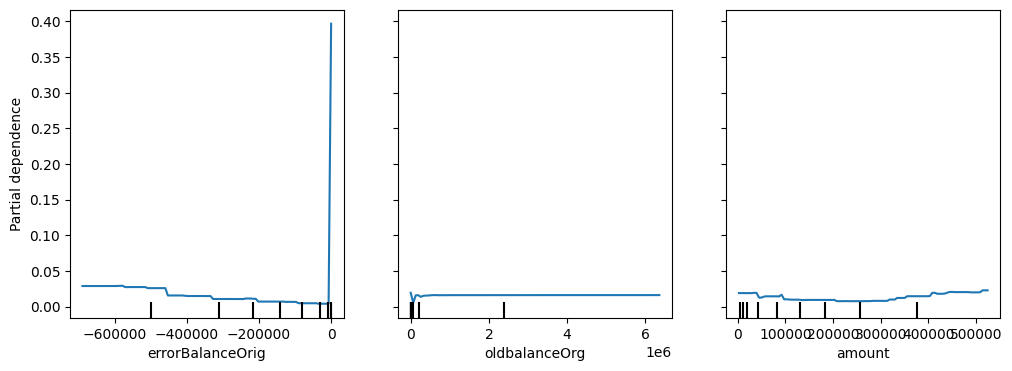

In [80]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
PartialDependenceDisplay.from_estimator(
    rf, pdp_sample, features=['errorBalanceOrig', 'oldbalanceOrg', 'amount'], ax=ax
)
plt.show()

In [81]:
balance_tier = pd.qcut(X_test['oldbalanceOrg'].rank(method='first'), q=4,
                        labels=['Q1_lowest', 'Q2', 'Q3', 'Q4_highest'])

for label in ['Q1_lowest', 'Q2', 'Q3', 'Q4_highest']:
    mask = balance_tier == label
    y_subset = y_test[mask]
    pred_subset = pred_test[mask.values]
    recall = recall_score(y_subset, pred_subset)
    print(f"{label}: Recall = {recall:.4f}  (n={mask.sum()}, fraud cases={y_subset.sum()})")

Q1_lowest: Recall = 0.3000  (n=477197, fraud cases=10)
Q2: Recall = 0.9907  (n=477196, fraud cases=107)
Q3: Recall = 0.9978  (n=477196, fraud cases=452)
Q4_highest: Recall = 1.0000  (n=477197, fraud cases=1895)


In [82]:
for label in ['Q1_lowest', 'Q2', 'Q3', 'Q4_highest']:
    mask = balance_tier == label
    y_subset = y_test[mask]
    pred_subset = pred_test[mask.values]
    precision = precision_score(y_subset, pred_subset)
    print(f"{label}: Precision = {precision:.4f}")

Q1_lowest: Precision = 1.0000
Q2: Precision = 1.0000
Q3: Precision = 1.0000
Q4_highest: Precision = 1.0000


In [83]:
for label in ['Q1_lowest', 'Q4_highest']:
    mask = (balance_tier == label) & (y_test == 1)
    print(f"{label} fraud cases — mean errorBalanceOrig: {X_test.loc[mask, 'errorBalanceOrig'].mean():.2f}")

Q1_lowest fraud cases — mean errorBalanceOrig: -205753.75
Q4_highest fraud cases — mean errorBalanceOrig: -8271.53


In [84]:
rows = []
for label in ['Q1_lowest', 'Q2', 'Q3', 'Q4_highest']:
    mask = (balance_tier == label).values
    yt = y_test.values[mask]
    yp = pred_test[mask]
    tp = ((yt == 1) & (yp == 1)).sum()
    fp = ((yt == 0) & (yp == 1)).sum()
    fn = ((yt == 1) & (yp == 0)).sum()
    tn = ((yt == 0) & (yp == 0)).sum()
    rows.append({
        'Tier': label,
        'Fraud cases': int(yt.sum()),
        'Base fraud rate': yt.mean(),
        'Selection rate': yp.mean(),
        'TPR (Recall)': tp / (tp + fn) if (tp + fn) else np.nan,
        'FPR': fp / (fp + tn) if (fp + tn) else np.nan,
    })

fairness_df = pd.DataFrame(rows).set_index('Tier')

dp_diff = fairness_df['Selection rate'].max() - fairness_df['Selection rate'].min()
tpr_gap = fairness_df['TPR (Recall)'].max() - fairness_df['TPR (Recall)'].min()
fpr_gap = fairness_df['FPR'].max() - fairness_df['FPR'].min()
di_ratio = fairness_df['Selection rate'].min() / fairness_df['Selection rate'].max()

print(fairness_df)
print(f"\nDemographic parity difference: {dp_diff:.6f}")
print(f"Equalized odds - TPR gap:      {tpr_gap:.4f}")
print(f"Equalized odds - FPR gap:      {fpr_gap:.6f}")
print(f"Disparate impact ratio:        {di_ratio:.5f}  (below 0.8 = common flag)")

            Fraud cases  Base fraud rate  Selection rate  TPR (Recall)  FPR
Tier                                                                       
Q1_lowest            10         0.000021        0.000006      0.300000  0.0
Q2                  107         0.000224        0.000222      0.990654  0.0
Q3                  452         0.000947        0.000945      0.997788  0.0
Q4_highest         1895         0.003971        0.003971      1.000000  0.0

Demographic parity difference: 0.003965
Equalized odds - TPR gap:      0.7000
Equalized odds - FPR gap:      0.000000
Disparate impact ratio:        0.00158  (below 0.8 = common flag)


**Fairness Analysis:** The dataset from PaySim does not contain demographic attributes. In lieu of this, the account balance quartiles are used to create the customer segmentation.
*   Equalized odds - TPR gap of 0.70 show that the lowest-balance quartile only has 30% fraud cases that are caught, compared with Q2 to Q4 quartiles with 99-100%. The FPR gap shows that no tier has been overflagged. However, this still shows the gap with Q1 quartile / lowest-balance group of customers.
*   For the Q1 fraud cases, 3 out of 10 have errorBalance of 0; the other 7 have large errors.
*   Disparate impact ratio of 0.0016 is misleading as fraud base rates vary across the tiers.

**Mitigation recommendations:**
*   Mitigation recommendation is to do a relative balance-error feature which looks at the percentage rather than the amount to keep the mechanism to look at the small and large accounts from the same lens. Once confirmed, leverage this to live data to determine actual results.
*   Additionally, decision threshold in the
lower-balance / Q1 tier can be lowered. Precision in this tier is 1.0 so more fraud can be caught before getting false-positive tags.





In [85]:
mask = (balance_tier == 'Q1_lowest') & (y_test == 1)
X_test.loc[mask, 'errorBalanceOrig']

,errorBalanceOrig
5996408,0.000000e+00
543928,-2.329230e+04
732891,-1.124865e+05
169998,-1.496687e+05
77745,-2.779709e+05
25875,-1.078014e+06
14861,-1.817281e+05
6362585,0.000000e+00
6351226,0.000000e+00
694551,-2.343773e+05


**Limitations:**

1. Baseline of fraud tagging is not reliable. With the existing flag (isFlaggedFraud) that caught 16 out of 8,213 fraud cases (0.19%) strongly suggests the objective of looking at a different model to capture fraudulent transactions and prevent further losses. This is a shift from a rule-based detection to a machine-learning approach.

2. There is subjective judgement of the final feature selection. While type_CASH_OUT ranked low in the Random Forest importance, it was still kept. This shows dependency of domain expertise or the one driving the initiative.

3. Importance of hyperparameter tuning. XGBoost's scale_pos_weight, when set to the true class ratio of 773.7 yielded a Precision of 0.159. Results are sensitive to tuning choices.

4. The two engineered features - errorBalanceOrig and errorBalanceDest significantly drove the model performance. If those were removed, the PR-AUC collapses from 0.997 to 0.126. This is because the dataset forces newBalanceOrig to be 0 on fraudulent transfers.

5. Partial dependence plots are unable to detect interaction effects. PDP showed oldBalanceOrg and amount as flat, despite having importance ranking in Random Forest and SHAP. This is a structural limitation as PDP averages sample while looking at one feature at a time. This cannot capture the effects when combined with other features.

6. With this synthetic dataset, it does not automatically guarantee applicability to live data. Certain parameters need to be adjusted accordingly to real-world data to ensure success.

**Step 6: Final Presentation & Communication**

Two deliverables for mixed audiences:
Technical presentation (Jupyter slides / LaTeX Beamer) → peers.
Business-facing presentation (PowerPoint / Canva) → executives (ROI, risks, strategy).
8–12 slides per deck recommended.
Deliverables: Two slide decks (technical + business).

*Presentations are uploaded separately.*

**Step 7: GitHub Profile & Upload**

Create a public GitHub repo  structured like an Open Source project:
Include: src/ for scripts, notebooks/, data/, models/ directories.
Deliverables: GitHub repo link + final report + reproducible code.

GitHub repo link: https://github.com/mnltn/fraud-detection-capstone